## <span style="color:red"> 1. A code cell is given that defines a function with one input argument (a number) and one return value (a string). Then a variable is defined, passed to the function, and the output is printed. However, there is a mistake in the code and an error occurs. You have to add a comment to the offending line, briefly explaining what happened. Then run a corrected version of the code in another cell. </span>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def describe_num(x):
    if x > 0:
        return "Positive number: " + x      # the error is here: concatenation relies on both objects to be strings; we need to convert x to string 
    else:
        return "Zero or negative"
        
n = -5
print(describe_num(n))

In [1]:
def describe_num(x):
    if x > 0:
        return "Positive number: " + str(x)
    else:
        return "Zero or negative"

n = -5
print(describe_num(n))


Zero or negative


## <span style="color:red"> 2. A code cell is given that defines two lists of numbers, then attempts to define a Numpy array from the entries of the two lists using a mathematical operation. The code cell runs fine, but the output is different than what was intended. You have to add a comment, briefly explaining why the output of the code is doing something differently. Then run a corrected version of the code in another cell. </span>

In [ ]:
import numpy as np

# see lect 8

a = [1, 2, 3]
b = [4, 5, 6]
arr = np.array([a, b]) * 2  # here we creae a 2x3 matrix and multiply each element of a and b by 2
print(arr)

[[ 2  4  6]
 [ 8 10 12]]


In [3]:
import numpy as np
a = [1, 2, 3]
b = [4, 5, 6]
arr = np.array(a) + np.array(b)
print(arr)

[5 7 9]


## <span style="color:red"> 3. Create a DataFrame by reading in a .csv file. The instructions will refer to a specific column/variable of the DataFrame, and a logical condition.  You will be instructed to extract the subset of the data for which this column/variable satisfies the logical condition. The extracted subset should be saved to a separate DataFrame. Then using Python commands, you will need to print out the number of rows in the extracted data set (i.e., how many rows satisfied the logical condition). </span>

In [14]:
import pandas as pd

# lecture 11 query 

cars = pd.read_csv("features.csv")
high_milage_cars = cars.query("mpg > 30")
print(high_milage_cars)

len(high_milage_cars)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
53   31.0          4            71         65    1773          19.0  T-1690363
54   35.0          4            72         69    1613          18.0  D-1690374
129  31.0          4            79         67    1950          19.0  D-1691199
131  32.0          4            71         65    1836          21.0  T-1691221
144  31.0          4            76         52    1649          16.5  T-1691364
..    ...        ...           ...        ...     ...           ...        ...
390  32.0          4           144         96    2665          13.9  T-1694070
391  36.0          4           135         84    2370          13.0  D-1694081
394  44.0          4            97         52    2130          24.6  V-1694114
395  32.0          4           135         84    2295          11.6  D-1694125
397  31.0          4           119         82    2720          19.4  C-1694147

[85 rows x 7 columns]


85

## <span style="color:red"> 4. Write a function that takes in a single number as an input argument, and returns a single string as the output. The value of the output string is one of two choices, which is determined by whether the input satisfies a logical condition. Then use the .apply() method from Pandas to evaluate this function for every row in a DataFrame. You will be told which column/variable should be input to the function. </span>

In [17]:
# lect 11 .apply

def efficiency_label (mpg):
    if mpg >= 25:
        return "High Efficiency"
    else: 
        return "Low Efficiency"

cars['efficiency'] = cars['mpg'].apply(efficiency_label)
print(cars.head())

    mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id  \
0  18.0          8           307        130    3504          12.0  C-1689780   
1  15.0          8           350        165    3693          11.5  B-1689791   
2  18.0          8           318        150    3436          11.0  P-1689802   
3  16.0          8           304        150    3433          12.0  A-1689813   
4  17.0          8           302        140    3449          10.5  F-1689824   

       efficiency  
0  Low Efficiency  
1  Low Efficiency  
2  Low Efficiency  
3  Low Efficiency  
4  Low Efficiency  


## <span style="color:red"> 5. Given a DataFrame, you will want to randomly assign each row to one of two groups. To do so, you will add a new column to the DataFrame called "random_var" which is filled with random numbers from a given distribution. Then you will create two new DataFrames, based on the whether each row's random variable satisfies a given logical condition. These two DataFrames represent the random assignment into two groups. </span>

In [ ]:
# lect 11 for random assignment

import numpy as np
import pandas as pd

# read dataset
df = pd.read_csv("features.csv")

# get number of rows
num_rows, num_cols = df.shape

# create a random variable (uniformly distributed between 0 and 1)
random_var = np.random.rand(num_rows)

# add new column to DataFrame
df["random_var"] = random_var

# create two groups using a logical condition on the random variable
group_A = df.query("random_var <= 0.5")
group_B = df.query("random_var > 0.5")

# print number of rows in each group
print("Group A rows:", len(group_A))
print("Group B rows:", len(group_B))


Group A rows: 199
Group B rows: 199


## <span style="color:red"> 6. Continuing question 5, you will make two scatter plots from the data in each randomly assigned group. So that they appear side-by-side, you will need to use the subplots command from the matplotlib.pyplot library. </span>

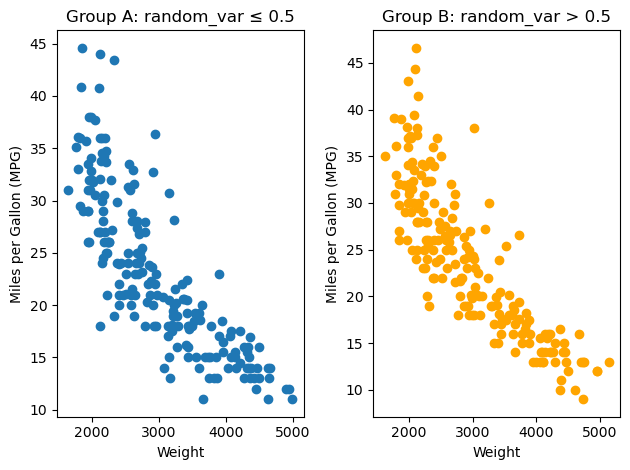

In [21]:
import matplotlib.pyplot as plt
# create side-by-side subplots
fig, sub_p = plt.subplots(nrows = 1, ncols = 2)

# left plot: group A
sub_p[0].scatter(x = group_A["weight"], y = group_A["mpg"])
sub_p[0].set_xlabel("Weight")
sub_p[0].set_ylabel("Miles per Gallon (MPG)")
sub_p[0].set_title("Group A: random_var ≤ 0.5")

# right plot: group B
sub_p[1].scatter(x = group_B["weight"], y = group_B["mpg"], color = "orange")
sub_p[1].set_xlabel("Weight")
sub_p[1].set_ylabel("Miles per Gallon (MPG)")
sub_p[1].set_title("Group B: random_var > 0.5")

# adjust layout and display
plt.tight_layout()
plt.show()